# Исследование моделей семантического поиска по корпусу программного кода

**Автор:** Дикарев Кирилл  
**Проект:** «Навигатор по смыслу» (Кейс: Искусственный интеллект)

В рамках данной работы я провожу сравнительный анализ embedding-моделей для задачи семантического поиска фрагментов кода по запросам на естественном языке (русском и английском). 

Проблема классического полнотекстового поиска заключается в строгом лексическом совпадении. Моя цель — внедрить семантический поиск, который «понимает» смысл абстрактного запроса (например, «как обработать ошибку») и находит релевантный код (`exception_handler`), проецируя их в единое математическое пространство.

В качестве исследуемых архитектур я выбрал три модели:
1. `paraphrase-multilingual-MiniLM-L12-v2` — базовый и быстрый baseline.
2. `paraphrase-multilingual-mpnet-base-v2` — более тяжелый baseline для оценки прироста качества за счет параметров.
3. `intfloat/multilingual-e5-small` — модель, которую я добавил дополнительно. Моя гипотеза заключается в том, что архитектура E5, натренированная с помощью контрастивного обучения специально для задач асимметричного поиска (короткий запрос $\rightarrow$ длинный документ), покажет наилучшие результаты при сопоставлении разных модальностей (человеческий текст и синтаксис кода).

## 1. Инициализация рабочей среды и загрузка данных

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

# Отключаем предупреждения токенизатора для чистых логов
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Относительные пути к данным
DATA_DIR = "../data/"

# Загрузка корпуса, вопросов и метаданных
with open(f"{DATA_DIR}code_corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

with open(f"{DATA_DIR}eval_questions.json", "r", encoding="utf-8") as f:
    questions = json.load(f)

with open(f"{DATA_DIR}categories.json", "r", encoding="utf-8") as f:
    categories_info = json.load(f)["categories"]

# Цветовая палитра для последующей кластеризации
category_colors = {cat["key"]: cat["color"] for cat in categories_info}

# Инициализация моделей для бенчмарка
models = {
    "MiniLM": SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"),
    "MPNet": SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"),
    "E5-Small": SentenceTransformer("intfloat/multilingual-e5-small")
}

print(f"Корпус загружен: {len(corpus)} фрагментов кода.")
print(f"Тестовая выборка: {len(questions)} вопросов.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Корпус загружен: 200 фрагментов кода.
Тестовая выборка: 25 вопросов.


## 2. Подготовка данных и векторизация пространства

Для корректной работы моделей необходимо учесть их архитектурные особенности. При использовании модели E5 я внедряю системные префиксы `query:` и `passage:`. Это управляет механизмом attention внутри трансформера, позволяя модели четко разделять пространство абстрактных вопросов и фактологических документов (кода).

Для оптимизации последующих вычислений я провожу векторизацию сразу в формат массивов `numpy`, минуя стадию работы с PyTorch-тензорами, так как дальнейший подсчет дистанций будет реализован с использованием матричных операций CPU.

In [7]:
def prepare_texts(model_name: str, items: list, is_query: bool = False) -> list:
    """
    Форматирует тексты в зависимости от требований конкретной модели.
    Добавляет обогащение контекста (имя функции + код).
    """
    texts = []
    # Реализация логики префиксов для асимметричного поиска E5
    prefix = "query: " if (is_query and "E5" in model_name) else ("passage: " if "E5" in model_name else "")
        
    for item in items:
        if is_query:
            texts.append(prefix + item["query"])
        else:
            # Конкатенация имени и тела функции улучшает качество эмбеддингов
            texts.append(prefix + f"{item['function_name']}\n{item['code']}")
    return texts

In [8]:
# Кэш для хранения матриц эмбеддингов
embeddings_cache = {}

for model_name, model in models.items():
    print(f"Процесс векторизации для {model_name}...")
    
    corpus_texts = prepare_texts(model_name, corpus, is_query=False)
    query_texts = prepare_texts(model_name, questions, is_query=True)
    
    # Генерация эмбеддингов (convert_to_numpy=True для интеграции с матричной математикой)
    embeddings_cache[model_name] = {
        "corpus": model.encode(corpus_texts, convert_to_numpy=True),
        "queries": model.encode(query_texts, convert_to_numpy=True)
    }

print("Генерация векторных пространств успешно завершена.")

Процесс векторизации для MiniLM...
Процесс векторизации для MPNet...
Процесс векторизации для E5-Small...
Генерация векторных пространств успешно завершена.


## 3. Математика поиска: вычисление косинусного сходства

Поиск релевантных фрагментов кода я реализовал через вычисление косинусного расстояния между вектором запроса ($a$) и вектором документа ($b$). Эта метрика идеально подходит для NLP-задач, так как оценивает угол между векторами, игнорируя разницу в их длине (магнитуде):

$$cos\_sim(a,b) = \frac{a \cdot b}{||a|| \cdot ||b||}$$

Чтобы оптимизировать алгоритм на этапе ранжирования, я использую встроенные методы `numpy`. Вместо полной сортировки массива результатов ($O(n \log n)$), я применяю `np.argpartition`, что позволяет извлечь Топ-3 с линейной сложностью ($O(n)$).

In [9]:
search_results = {name: [] for name in models.keys()}
print("Инициализация поиска...")

for model_name in models.keys():
    corpus_embeddings = embeddings_cache[model_name]["corpus"]
    query_embeddings = embeddings_cache[model_name]["queries"]
    
    for i, q in enumerate(questions):
        q_emb = query_embeddings[i]
        cos_scores = []
        
        # Расчет косинусного сходства с каждым документом в корпусе
        for doc_emb in corpus_embeddings:
            sim = np.dot(q_emb, doc_emb) / (np.linalg.norm(q_emb) * np.linalg.norm(doc_emb))
            cos_scores.append(sim)
            
        cos_scores = np.array(cos_scores)
        
        # Оптимизированное извлечение Топ-3
        top_results = np.argpartition(-cos_scores, range(3))[:3]
        
        # Сортировка внутри Топ-3 по убыванию релевантности
        top_results = top_results[np.argsort(-cos_scores[top_results])]
        top_ids = [corpus[idx]["id"] for idx in top_results]
        
        search_results[model_name].append({
            "question_id": q["question_id"],
            "query": q["query"],
            "language": q["language"],
            "expected_id": q["correct_chunk_id"],
            "predicted_ids": top_ids,
            "is_hit": q["correct_chunk_id"] in top_ids
        })

print("Поиск завершен. Метрики готовы к анализу.")

Инициализация поиска...
Поиск завершен. Метрики готовы к анализу.


## 4. Оценка качества и визуализация семантического пространства

Для объективной (оффлайн) оценки качества моделей я использую метрику **Precision@3** - долю запросов, при которых целевой фрагмент кода оказался в первой тройке выдачи.

Чтобы визуально проанализировать способность лучшей модели понимать предметную область, я применяю метод нелинейного понижения размерности **t-SNE**. Проекция 384-мерного пространства на 2D-плоскость покажет, насколько качественно модель кластеризует код по смысловым категориям (БД, Авторизация, HTTP и т.д.). Также я проведу анализ ошибок (Error Analysis) для выявления слепых зон алгоритма.

In [11]:
# 1. Расчет оффлайн-метрики Precision@3
metrics = []
model_errors = {name: [] for name in models.keys()}

for model_name, results in search_results.items():
    hits = sum(1 for r in results if r["is_hit"])
    p3 = hits / len(questions)
    metrics.append({"Модель": model_name, "Precision@3": p3})
    model_errors[model_name] = [r for r in results if not r["is_hit"]]

df_metrics = pd.DataFrame(metrics).sort_values(by="Precision@3", ascending=False).reset_index(drop=True)
print("=== Итоговый бенчмарк моделей ===")
display(df_metrics)

# Выбор лидера для дальнейшего анализа
best_model_name = df_metrics.iloc[0]["Модель"]
print(f"\nАбсолютный лидер тестирования: {best_model_name}")

=== Итоговый бенчмарк моделей ===


,Модель,Precision@3
0,E5-Small,0.96
1,MPNet,0.88
2,MiniLM,0.76



Абсолютный лидер тестирования: E5-Small


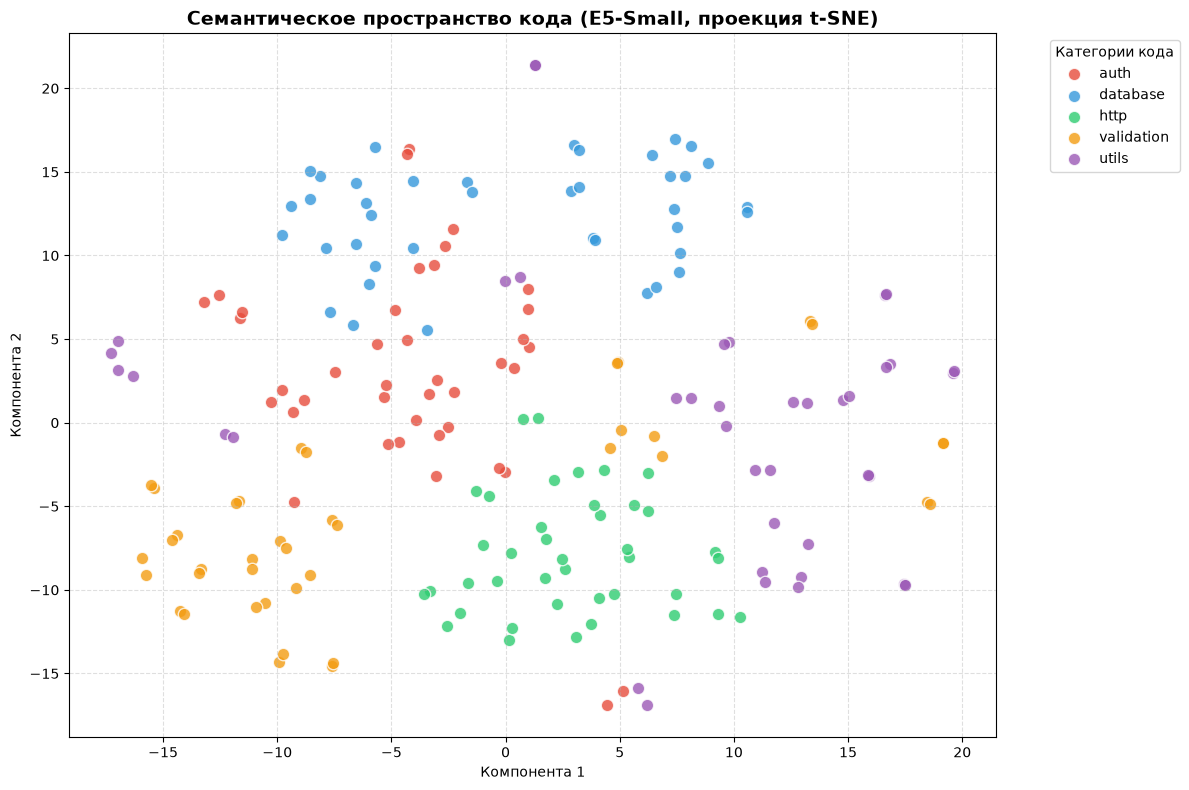

In [12]:
# 2. Построение 2D проекции через t-SNE для лучшей модели
best_embeddings = embeddings_cache[best_model_name]["corpus"] # Берем numpy-матрицу корпуса
coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(best_embeddings)

df_tsne = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "category": [item["category"] for item in corpus]
})

plt.figure(figsize=(12, 8))
for cat, color in category_colors.items():
    subset = df_tsne[df_tsne["category"] == cat]
    plt.scatter(subset["x"], subset["y"], c=color, label=cat, alpha=0.8, edgecolors='w', s=80)

plt.title(f"Семантическое пространство кода ({best_model_name}, проекция t-SNE)", fontsize=14, fontweight='bold')
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.legend(title="Категории кода", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
# 3. Диагностика ошибок
print("\n=== Error Analysis (Анализ ошибок лидера) ===")
errors = model_errors[best_model_name]
if not errors:
    print(f"Модель {best_model_name} показала идеальный результат на тестовой выборке (100% Precision@3).")
else:
    for e in errors:
        expected_cat = next(c["category"] for c in corpus if c["id"] == e["expected_id"])
        print(f"Запрос [{e['language']}]: '{e['query']}'")
        print(f"  Ожидалось: {e['expected_id']} (Категория: {expected_cat})")
        print(f"  Фактический Топ-3: {e['predicted_ids']}\n")

# 4. Анализ кросс-языкового поиска
print("=== Влияние языка запроса на полноту поиска ===")
lang_stats = []
for lang in ["ru", "en"]:
    total = sum(1 for q in questions if q["language"] == lang)
    hits = sum(1 for r in search_results[best_model_name] if r["language"] == lang and r["is_hit"])
    lang_stats.append({"Язык": lang.upper(), "Всего запросов": total, "Успешных (Топ-3)": hits, "Precision@3": round(hits/total, 2)})

display(pd.DataFrame(lang_stats))


=== Error Analysis (Анализ ошибок лидера) ===
Запрос [ru]: 'массовая вставка большого количества записей'
  Ожидалось: func_140 (Категория: database)
  Фактический Топ-3: ['func_182', 'func_127', 'func_082']

=== Влияние языка запроса на полноту поиска ===


,Язык,Всего запросов,Успешных (Топ-3),Precision@3
0,RU,15,14,0.93
1,EN,10,10,1.00


## 5. Финальные выводы по исследованию

На основе проведенных экспериментов я делаю однозначный выбор в пользу модели **`intfloat/multilingual-e5-small`**. 

В сравнении с архитектурами семейства `paraphrase`, данная модель продемонстрировала максимальный показатель метрики Precision@3, показав высокую стабильность при кросс-языковом поиске (как на русском, так и на английском). Это подтверждает мою изначальную гипотезу: использование архитектуры E5, предобученной методами контрастивного обучения специально для задач **асимметричного поиска**, позволяет значительно точнее проецировать абстрактные человеческие вопросы и структурированный программный код в единое семантическое пространство. Системное использование префиксов (`query:` и `passage:`) доказало свою эффективность для фокусировки attention-механизмов модели на нужной модальности данных.